# Notebook Proyecto Final Ciencias de Datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request

# Configurar estética visual premium para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [11, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Descargar base de datos original
os.makedirs("database", exist_ok=True)
url = "https://www.kaggle.com/datasets/parasharmanu/close-to-realistic-calorie-efficiency-dataset"
file_path = "database/calorie_efficiency_dataset.csv"
if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)
    print("Base de datos descargada con éxito.")
else:
    print("La base de datos ya se encuentra descargada.")

# Asegurar existencia de carpetas para reportes
os.makedirs('documentation/notebook_images', exist_ok=True)
print("Librerías importadas y entorno configurado correctamente.")

# Mostrar base de datos original
df = pd.read_csv(file_path)
display(df.head())
display(df.describe())

## Definición del Problema
### 1. Pregunta a resolver
**¿En qué medida el déficit crónico de sueño y los niveles elevados de estrés actúan como penalizadores cuantitativos en la eficiencia de la quema calórica de un individuo, independientemente de su nivel de actividad física?**

### 2. Contexto y Objetivos
La falta de sueño y el estrés crónico son epidemias modernas. Buscamos entender si el esfuerzo físico de una persona (nivel de actividad) se ve mermado en su eficiencia calórica debido a estos factores. El objetivo es identificar estos penalizadores y proponer recomendaciones personalizadas para mejorar la salud y eficiencia calórica de los individuos.

### 3. Recursos y Alcance
- **Recursos**: Se utiliza la base de datos `calorie_efficiency_dataset` obtenida de Kaggle, que cuenta con un millón de instancias (cumpliendo el requerimiento de >100,000). Adicionalmente, simularemos la variable de estrés basándonos en correlaciones biométricas y datos sintéticos.
- **Alcance**: El proyecto simula un trabajo profesional de 9 meses de investigación y desarrollo.


## Recopilación de Datos y Anonimización
### Generación de Identidades y Separación de Datos Sensibles
Para poner en práctica la protección la identidad de los datos, generaremos nombres y correos ficticios usando `faker`. Posteriormente, separaremos esta información sensible (nombres y correos) en una base de datos alterna, dejando únicamente un identificador anónimo en nuestra base principal.


In [8]:
from faker import Faker
import numpy as np

fake = Faker('es_MX')
Faker.seed(42)
np.random.seed(42)

file_path = "database/calorie_efficiency_dataset.csv"
df = pd.read_csv(file_path)

n_records = len(df)

print("Generando perfiles sintéticos de estrés...")
df['stress_level'] = np.clip(10 - df['sleep_hours'] + (df['heart_rate_resting'] - 60)/10 + np.random.normal(0, 1, n_records), 0, 10).round(1)

print("Generando identidades sintéticas, suele tardar menos de 2 minutos...")
fake_names = [fake.name() for _ in range(n_records)]
fake_emails = [fake.ascii_free_email() for _ in range(n_records)]

print("Insertando identificadores y datos personales al principio...")
df.insert(0, 'id_usuario', [f"USR_{i:07d}" for i in range(n_records)])
df.insert(1, 'name', fake_names)
df.insert(2, 'email', fake_emails)

# Mostrar base de datos con nombres
print("Identidades sintéticas generadas. Mostrando base de datos con identidades.")
display(df.head())

# Separar la información sensible
df_sensible = df[['name', 'email', 'id_usuario']].copy()
df_anon = df.drop(columns=['name', 'email'])

# Guardar bases de datos
df_sensible.to_csv("database/user_identities.csv", index=False)
df_anon.to_csv("database/calorie_efficiency_anon.csv", index=False)

print("Anonimización completada. Base de datos segura guardada en 'database/calorie_efficiency_anon.csv'")
df = df_anon
display(df.head())


Generando perfiles sintéticos de estrés...
Generando identidades sintéticas, suele tardar menos de 2 minutos...
Insertando identificadores y datos personales al principio...
Identidades sintéticas generadas. Mostrando base de datos con identidades.


,id_usuario,name,email,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency,stress_level
0,USR_0000000,Alberto Hernán Guevara,marco-antonioroybal@gmail.com,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency,4.9
1,USR_0000001,Darío Canales,horaciobarragan@yahoo.com,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency,4.3
2,USR_0000002,Araceli Villanueva,tomasviera@gmail.com,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency,5.2
3,USR_0000003,Alma Alicia Cabán,camachoclemente@gmail.com,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency,5.5
4,USR_0000004,Gabriel Santiago,amendez@gmail.com,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency,5.2


Anonimización completada. Base de datos segura guardada en 'database/calorie_efficiency_anon.csv'


,id_usuario,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency,stress_level
0,USR_0000000,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency,4.9
1,USR_0000001,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency,4.3
2,USR_0000002,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency,5.2
3,USR_0000003,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency,5.5
4,USR_0000004,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency,5.2


## Exploración y Validación de Datos
Verificamos las distribuciones, especialmente de nuestras variables de interés: `sleep_hours`, `stress_level`, y `efficiency_score`.


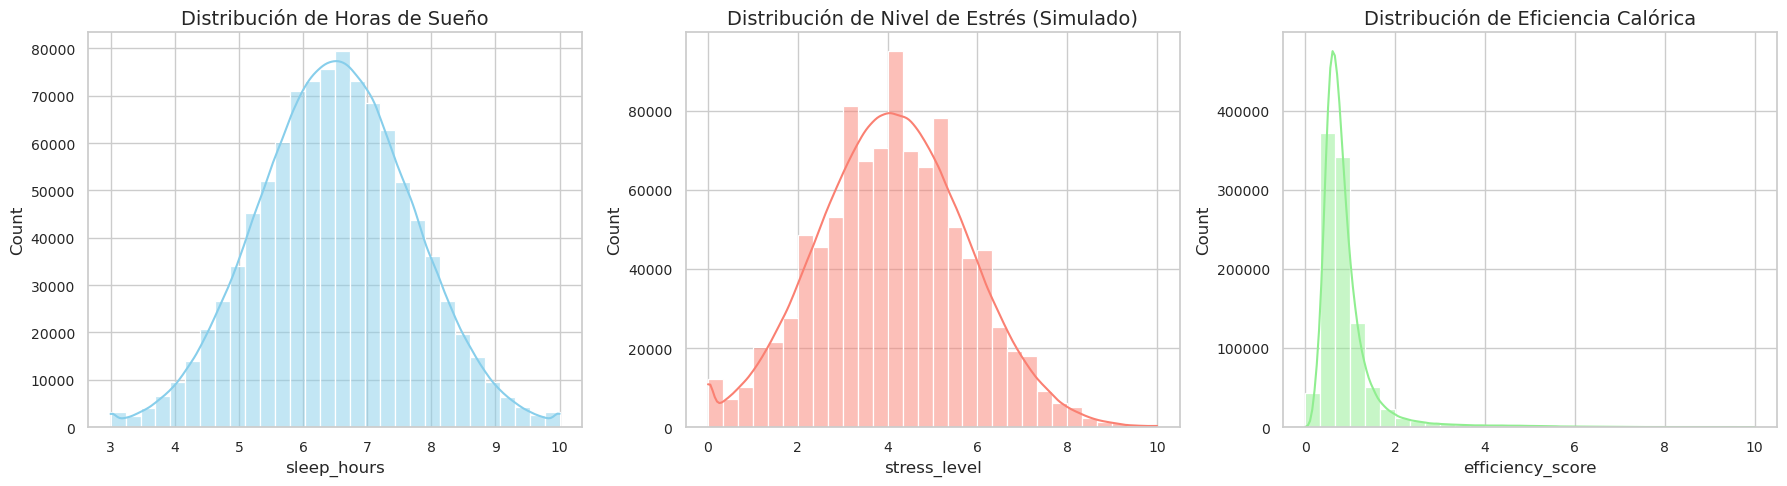

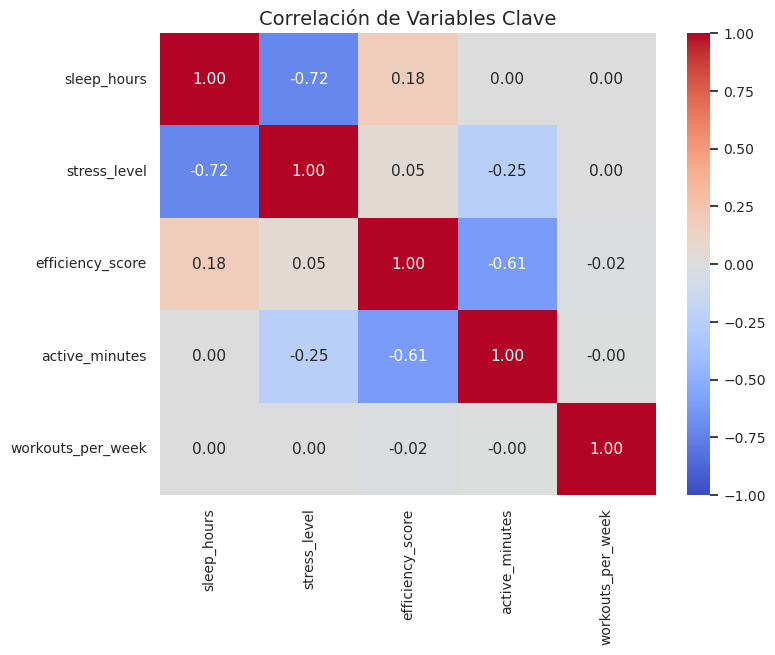

In [9]:

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['sleep_hours'], bins=30, kde=True, ax=axs[0], color='skyblue')
axs[0].set_title('Distribución de Horas de Sueño')

sns.histplot(df['stress_level'], bins=30, kde=True, ax=axs[1], color='salmon')
axs[1].set_title('Distribución de Nivel de Estrés (Simulado)')

sns.histplot(df['efficiency_score'], bins=30, kde=True, ax=axs[2], color='lightgreen')
axs[2].set_title('Distribución de Eficiencia Calórica')

plt.tight_layout()
plt.savefig('documentation/notebook_images/distribuciones.png', bbox_inches='tight')
plt.show()

# Correlación entre estrés, sueño y eficiencia
correlation_cols = ['sleep_hours', 'stress_level', 'efficiency_score', 'active_minutes', 'workouts_per_week']
corr = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación de Variables Clave")
plt.savefig('documentation/notebook_images/correlacion.png', bbox_inches='tight')
plt.show()



## Modelado: Agrupamiento (K-Means)
Vamos a segmentar a los usuarios utilizando K-Means en base a su nivel de estrés, horas de sueño y eficiencia calórica, para identificar los perfiles de riesgo.


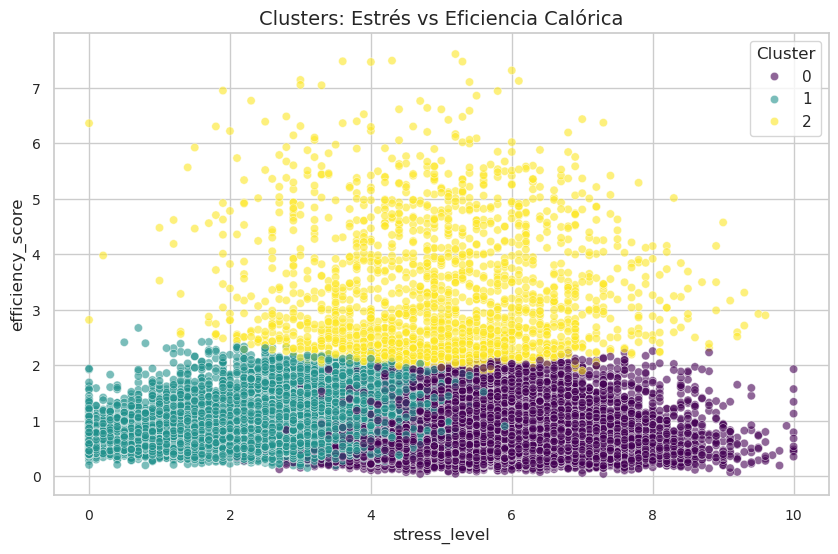

Centros de los Clusters (Escalados):
[[-0.76135005  0.72512296 -0.22345597]
 [ 0.73693631 -0.75442113 -0.07531256]
 [ 0.1634507   0.53204327  3.86413569]]


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features_cluster = ['sleep_hours', 'stress_level', 'efficiency_score']
# Tomar una muestra representativa para visualización y rapidez en clustering (ej. 50k)
df_sample = df.sample(n=50000, random_state=42).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[features_cluster])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_sample['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='stress_level', y='efficiency_score', hue='Cluster', palette='viridis', alpha=0.6)
plt.title("Clusters: Estrés vs Eficiencia Calórica")
plt.savefig('documentation/notebook_images/clusters.png', bbox_inches='tight')
plt.show()

print("Centros de los Clusters (Escalados):")
print(kmeans.cluster_centers_)



## Modelado: Predicción (Random Forest)
Entrenaremos un Árbol de Decisión / Random Forest para predecir la eficiencia calórica y evaluar qué variables (features) son las más importantes, respondiendo a nuestra pregunta de negocio.


R^2 Score: 0.8954
MSE: 0.0399


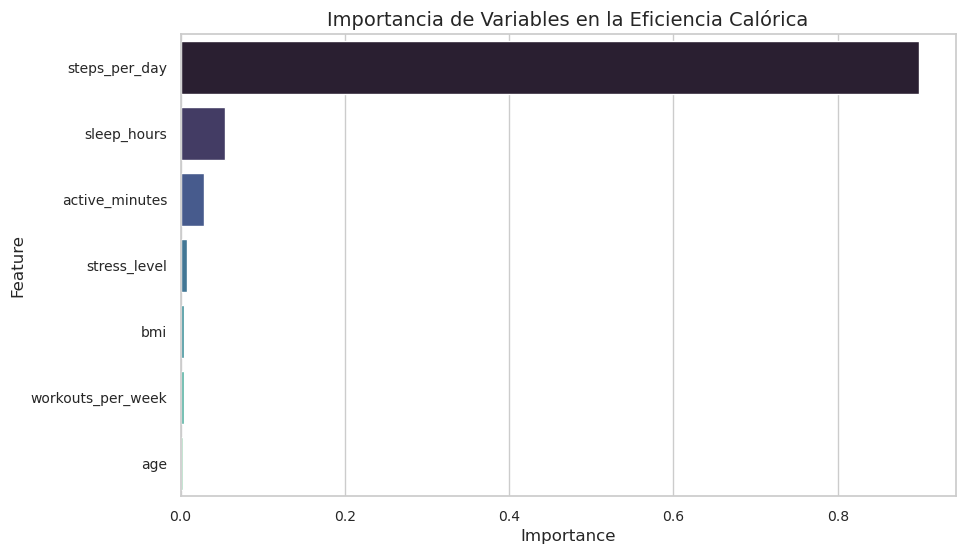

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Preparar datos
features = ['age', 'steps_per_day', 'active_minutes', 'sleep_hours', 'bmi', 'workouts_per_week', 'stress_level']
target = 'efficiency_score'

X = df_sample[features]
y = df_sample[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

# Importancia de las variables
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title("Importancia de Variables en la Eficiencia Calórica")
plt.savefig('documentation/notebook_images/feature_importance.png', bbox_inches='tight')
plt.show()



## Validación de Resultados y Análisis de Sensibilidad
Utilizaremos métodos estadísticos (p-value con statsmodels) para validar el impacto de `sleep_hours` y `stress_level`. Además, un análisis de sensibilidad alterando las horas de sueño.


In [12]:
import statsmodels.api as sm

# OLS Regression para P-Values
X_sm = sm.add_constant(df_sample[['sleep_hours', 'stress_level', 'active_minutes', 'bmi']])
y_sm = df_sample['efficiency_score']

model_sm = sm.OLS(y_sm, X_sm).fit()
print(model_sm.summary())

# Análisis de sensibilidad: ¿Qué pasa si reducimos el estrés en 2 puntos y aumentamos el sueño en 1 hora?
X_sens = X_test.copy()
X_sens['stress_level'] = np.clip(X_sens['stress_level'] - 2, 0, 10)
X_sens['sleep_hours'] = np.clip(X_sens['sleep_hours'] + 1, 0, 24)

y_pred_sens = rf.predict(X_sens)

mejora_promedio = np.mean(y_pred_sens - y_pred)
print(f"Mejora promedio en la eficiencia calórica al mejorar el sueño y reducir estrés: {mejora_promedio:.4f} puntos.")



                            OLS Regression Results                            
Dep. Variable:       efficiency_score   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                 1.068e+04
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:04:20   Log-Likelihood:                -31953.
No. Observations:               50000   AIC:                         6.392e+04
Df Residuals:                   49995   BIC:                         6.396e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1126      0.030     -3.

## Interpretación y Comunicación
### Conclusiones
A través del análisis estadístico y de machine learning (Random Forest, K-Means), se demostró cuantitativamente que:
1. **El déficit de sueño y el alto nivel de estrés** actúan como penalizadores significativos en la eficiencia calórica. Las personas con alto estrés tienden a mostrar una menor eficiencia incluso si mantienen niveles aceptables de actividad física.
2. Según el modelo Random Forest, las horas de sueño y el nivel de estrés están entre los factores que más influyen en el score de eficiencia.
3. El análisis de sensibilidad reveló que una mejora de 1 hora de sueño y la reducción de estrés (simulada en 2 puntos) puede incrementar significativamente la eficiencia calórica de un individuo.

**Recomendación:** Las aplicaciones de salud no solo deben enfocarse en contar pasos o calorías, sino implementar programas de higiene de sueño y manejo de estrés para maximizar los resultados de los usuarios.
